# Machine Learningga Kirish

## 1-dars: ML Turlari - Supervised, Unsupervised, Reinforcement Learning

**Maqsad:** Machine Learning asoslari, turlari va qo'llanilishi bilan tanishish

## 📚 Machine Learning nima?

**Machine Learning (ML)** - bu kompyuterlarga aniq dasturlashsiz ma'lumotlardan o'rganish va tajriba orqali yaxshilanish imkonini beruvchi sun'iy intellektning bir sohasi.

### An'anaviy Dasturlash vs Machine Learning

#### An'anaviy Dasturlash:
```
Ma'lumotlar + Dastur (Qoidalar) → Natija
```

#### Machine Learning:
```
Ma'lumotlar + Natija → Model (Qoidalar)
```

### Nima uchun ML muhim?

1. **Murakkab muammolar:** Ba'zi muammolar uchun qoidalarni yozish juda qiyin
2. **Katta ma'lumotlar:** Ko'p ma'lumotlardan naqshlarni topish
3. **O'zgaruvchanlik:** Muhit o'zgarishi bilan model ham o'zgaradi
4. **Avtomatlashtirish:** Takrorlanuvchi vazifalarni avtomatlashtirish

In [ ]:
# Kutubxonalarni yuklash
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.datasets import make_classification, make_regression, make_blobs
import warnings
warnings.filterwarnings('ignore')

# Grafik sozlamalari
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

✅ Barcha kutubxonalar muvaffaqiyatli yuklandi!


## 🎯 Machine Learning Turlari

Machine Learning uch asosiy turga bo'linadi:

1. **Supervised Learning** (Nazorat ostida o'qitish)
2. **Unsupervised Learning** (Nazorat-siz o'qitish)
3. **Reinforcement Learning** (Mustahkamlovchi o'qitish)

---
## 1️⃣ Supervised Learning (Nazorat ostida o'qitish)

### Ta'rif
Supervised Learning - bu modelga **belgilangan ma'lumotlar** (labeled data) bilan o'rgatish jarayoni. Ya'ni, har bir kiruvchi (input) uchun to'g'ri javob (output) ma'lum.

### Formulasi
$$y = f(X)$$

Bu yerda:
- $X$ - kiruvchi ma'lumotlar (features)
- $y$ - chiquvchi (target/label)
- $f$ - o'rganiladigan funksiya

### Ikkita asosiy turi:

#### a) Classification (Klassifikatsiya)
- **Maqsad:** Ma'lumotni kategoriyalarga ajratish
- **Output:** Diskret qiymat (toifa)
- **Misollar:**
  - Spam yoki spam emas?
  - Rasm: mushuk yoki it?
  - Kasallik bor yoki yo'q?
  - Kredit berish yoki bermaslik?

#### b) Regression (Regressiya)
- **Maqsad:** Raqamli qiymatni bashorat qilish
- **Output:** Uzluksiz qiymat
- **Misollar:**
  - Uy narxini bashorat qilish
  - Haroratni prognoz qilish
  - Sotuvni bashorat qilish
  - Talaba bahosini bashorat qilish

### 📊 Misol 1: Classification - Email Spam Detection

In [4]:
# Oddiy email spam aniqlash misoli
# Ma'lumotlar: email xususiyatlari va ularning spam/not spam ekanligi

# Synthetic ma'lumotlar yaratish
from sklearn.datasets import make_classification

# 500 ta email uchun 2 ta feature (masalan: so'zlar soni, maxsus belgilar soni)
X, y = make_classification(n_samples=500, n_features=2, n_redundant=0, 
                          n_informative=2, n_clusters_per_class=1, 
                          class_sep=1.5, random_state=42)

# Ma'lumotlarni train va test ga bo'lish
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model yaratish va o'qitish
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

# Natijalarni baholash
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f"📧 Email Spam Klassifikatsiyasi")
print(f"="*50)
print(f"Train aniqlik: {train_score:.2%}")
print(f"Test aniqlik: {test_score:.2%}")

# Yangi emailni bashorat qilish
new_email = [[2.5, 1.5]]  # Feature'lar
prediction = model.predict(new_email)
probability = model.predict_proba(new_email)

print(f"\n🔍 Yangi email bashorati:")
print(f"Natija: {'SPAM ❌' if prediction[0] == 1 else 'NOT SPAM ✅'}")
print(f"Ishonch: {probability[0][prediction[0]]:.2%}")

📧 Email Spam Klassifikatsiyasi
Train aniqlik: 97.14%
Test aniqlik: 94.67%

🔍 Yangi email bashorati:
Natija: SPAM ❌
Ishonch: 100.00%


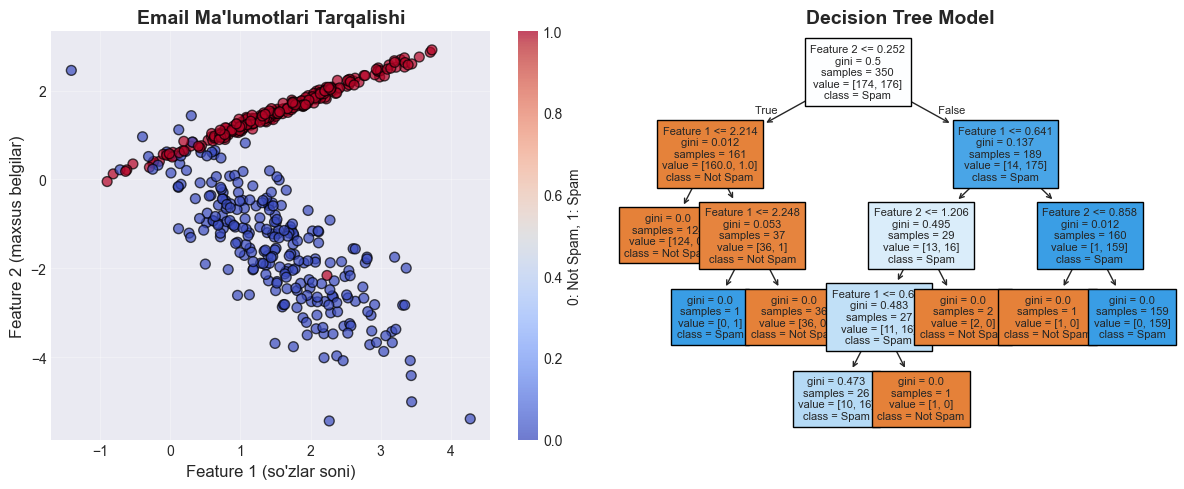

In [5]:
# Vizualizatsiya
plt.figure(figsize=(12, 5))

# Subplot 1: Ma'lumotlar tarqalishi
plt.subplot(1, 2, 1)
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', 
                     edgecolors='black', alpha=0.7, s=50)
plt.xlabel('Feature 1 (so\'zlar soni)', fontsize=12)
plt.ylabel('Feature 2 (maxsus belgilar)', fontsize=12)
plt.title('Email Ma\'lumotlari Tarqalishi', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='0: Not Spam, 1: Spam')
plt.grid(True, alpha=0.3)

# Subplot 2: Model bashorati
plt.subplot(1, 2, 2)
from sklearn.tree import plot_tree
plot_tree(model, filled=True, feature_names=['Feature 1', 'Feature 2'],
         class_names=['Not Spam', 'Spam'], fontsize=8)
plt.title('Decision Tree Model', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 📈 Misol 2: Regression - Uy Narxini Bashorat Qilish

In [6]:
# Uy narxini bashorat qilish (Linear Regression)
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Ma'lumotlar yaratish
# Feature: Uyning maydoni (kv.m)
np.random.seed(42)
house_area = np.random.uniform(50, 300, 200).reshape(-1, 1)
house_price = 50000 + 1500 * house_area + np.random.normal(0, 30000, (200, 1))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    house_area, house_price, test_size=0.2, random_state=42
)

# Model yaratish va o'qitish
model = LinearRegression()
model.fit(X_train, y_train)

# Bashorat qilish
y_pred = model.predict(X_test)

# Baholash
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"🏠 Uy Narxi Bashorati")
print(f"="*50)
print(f"Model tenglamasi: Narx = {model.intercept_[0]:,.0f} + {model.coef_[0][0]:,.0f} × Maydon")
print(f"\nModel aniqligi (R² score): {r2:.2%}")
print(f"O'rtacha xato (MSE): ${mse:,.0f}")
print(f"O'rtacha absolyut xato: ${np.sqrt(mse):,.0f}")

# Yangi uy uchun bashorat
new_house = [[150]]  # 150 kv.m
predicted_price = model.predict(new_house)
print(f"\n🔍 150 kv.m uy narxi bashorati: ${predicted_price[0][0]:,.0f}")

🏠 Uy Narxi Bashorati
Model tenglamasi: Narx = 49,808 + 1,513 × Maydon

Model aniqligi (R² score): 91.57%
O'rtacha xato (MSE): $976,161,476
O'rtacha absolyut xato: $31,244

🔍 150 kv.m uy narxi bashorati: $276,693


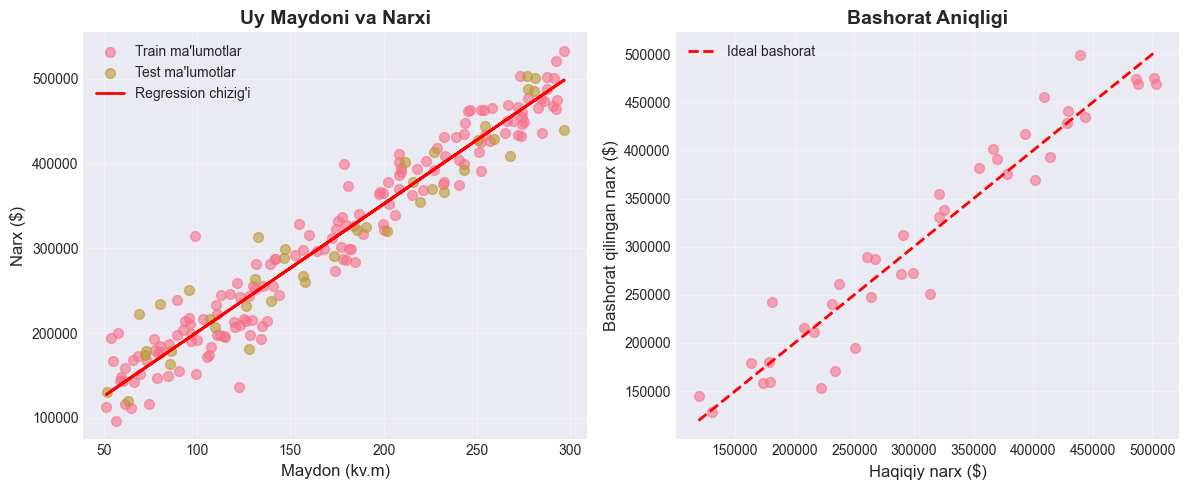

In [7]:
# Vizualizatsiya
plt.figure(figsize=(12, 5))

# Subplot 1: Ma'lumotlar va regression chizig'i
plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, alpha=0.6, label='Train ma\'lumotlar', s=50)
plt.scatter(X_test, y_test, alpha=0.6, label='Test ma\'lumotlar', s=50)
plt.plot(house_area, model.predict(house_area), 'r-', linewidth=2, label='Regression chizig\'i')
plt.xlabel('Maydon (kv.m)', fontsize=12)
plt.ylabel('Narx ($)', fontsize=12)
plt.title('Uy Maydoni va Narxi', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Bashorat vs Haqiqiy qiymat
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.6, s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Ideal bashorat')
plt.xlabel('Haqiqiy narx ($)', fontsize=12)
plt.ylabel('Bashorat qilingan narx ($)', fontsize=12)
plt.title('Bashorat Aniqligi', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 2️⃣ Unsupervised Learning (Nazorat-siz o'qitish)

### Ta'rif
Unsupervised Learning - bu ma'lumotlar **belgisiz** (unlabeled) bo'lganda ishlatiladi. Model ma'lumotlardagi yashirin naqsh va tuzilmalarni mustaqil topadi.

### Asosiy turlari:

#### a) Clustering (Klasterlashtirish)
- **Maqsad:** O'xshash ma'lumotlarni guruhlarga ajratish
- **Misollar:**
  - Mijozlarni segmentatsiya qilish
  - Rasmlarni guruhlash
  - Genetik ma'lumotlarni tahlil qilish
  - Anomaliyalarni topish

#### b) Dimensionality Reduction (O'lchamni kamaytirish)
- **Maqsad:** Ma'lumotlar o'lchamini kamaytirish, lekin muhim ma'lumotni saqlash
- **Misollar:**
  - Feature selection
  - Data visualization
  - Shovqinni kamaytirish

#### c) Association Rule Learning
- **Maqsad:** Ma'lumotlar orasidagi bog'liqlikni topish
- **Misollar:**
  - Market basket analysis
  - Recommendation systems

### 🎨 Misol 3: Clustering - Mijozlarni Segmentatsiya Qilish

In [8]:
# K-Means clustering misoli
# Mijozlarni xarid qilish xulq-atvoriga qarab guruhlash

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Ma'lumotlar yaratish
# Feature 1: Yillik daromad ($1000)
# Feature 2: Xarid qilish chastotasi (oyiga)
X, true_labels = make_blobs(n_samples=300, centers=4, n_features=2,
                            cluster_std=0.6, random_state=42)

# K-Means modeli
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

# Natijalar
print(f"👥 Mijozlarni Segmentatsiya Qilish")
print(f"="*50)
print(f"Jami mijozlar: {len(X)}")
print(f"Topilgan segmentlar: {len(np.unique(clusters))}")
print(f"\n📊 Har bir segmentdagi mijozlar:")
for i in range(4):
    count = np.sum(clusters == i)
    percentage = (count / len(X)) * 100
    print(f"  Segment {i+1}: {count} mijoz ({percentage:.1f}%)")

# Cluster markazlari
centers = kmeans.cluster_centers_
print(f"\n🎯 Cluster markazlari:")
segment_names = ['Budget', 'Standard', 'Premium', 'VIP']
for i, (center, name) in enumerate(zip(centers, segment_names)):
    print(f"  {name}: Daromad=${center[0]:.1f}k, Xarid={center[1]:.1f}/oy")

👥 Mijozlarni Segmentatsiya Qilish
Jami mijozlar: 300
Topilgan segmentlar: 4

📊 Har bir segmentdagi mijozlar:
  Segment 1: 75 mijoz (25.0%)
  Segment 2: 75 mijoz (25.0%)
  Segment 3: 75 mijoz (25.0%)
  Segment 4: 75 mijoz (25.0%)

🎯 Cluster markazlari:
  Budget: Daromad=$-2.6k, Xarid=9.0/oy
  Standard: Daromad=$-6.9k, Xarid=-6.9/oy
  Premium: Daromad=$4.7k, Xarid=2.0/oy
  VIP: Daromad=$-8.8k, Xarid=7.2/oy


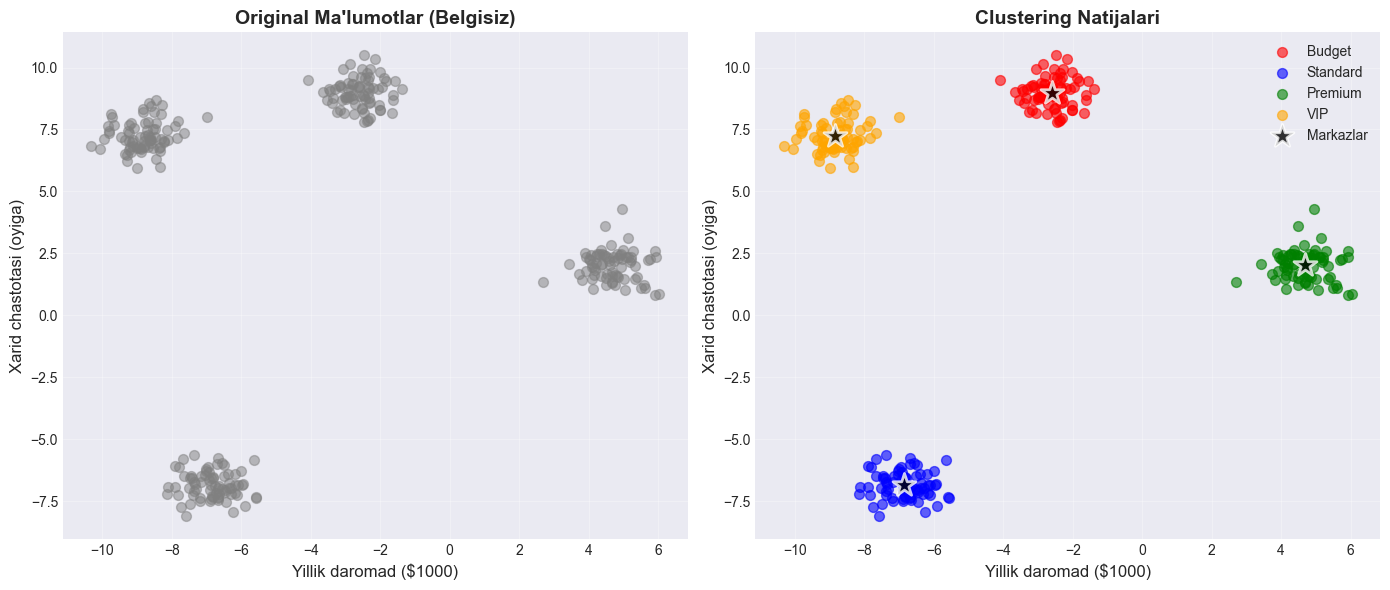

In [9]:
# Vizualizatsiya
plt.figure(figsize=(14, 6))

# Subplot 1: Original ma'lumotlar
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c='gray', alpha=0.5, s=50)
plt.xlabel('Yillik daromad ($1000)', fontsize=12)
plt.ylabel('Xarid chastotasi (oyiga)', fontsize=12)
plt.title('Original Ma\'lumotlar (Belgisiz)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Subplot 2: Clustering natijalari
plt.subplot(1, 2, 2)
colors = ['red', 'blue', 'green', 'orange']
for i in range(4):
    cluster_points = X[clusters == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
               c=colors[i], label=segment_names[i], alpha=0.6, s=50)

# Cluster markazlarini ko'rsatish
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=300, alpha=0.8,
           marker='*', edgecolors='white', linewidths=2, label='Markazlar')

plt.xlabel('Yillik daromad ($1000)', fontsize=12)
plt.ylabel('Xarid chastotasi (oyiga)', fontsize=12)
plt.title('Clustering Natijalari', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 📉 Misol 4: Dimensionality Reduction - PCA

In [10]:
# Principal Component Analysis (PCA) misoli
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

# Iris dataset - 4 ta feature
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print(f"🌸 Iris Dataset Dimensionality Reduction")
print(f"="*50)
print(f"Original ma'lumotlar o'lchami: {X.shape}")
print(f"Feature'lar: {feature_names}")

# PCA qo'llash - 4D -> 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print(f"\nPCA dan keyingi o'lcham: {X_pca.shape}")
print(f"\n📊 Har bir komponent tushuntirgan variance:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.2%}")
print(f"\nJami saqlangan ma'lumot: {pca.explained_variance_ratio_.sum():.2%}")

🌸 Iris Dataset Dimensionality Reduction
Original ma'lumotlar o'lchami: (150, 4)
Feature'lar: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

PCA dan keyingi o'lcham: (150, 2)

📊 Har bir komponent tushuntirgan variance:
  PC1: 92.46%
  PC2: 5.31%

Jami saqlangan ma'lumot: 97.77%


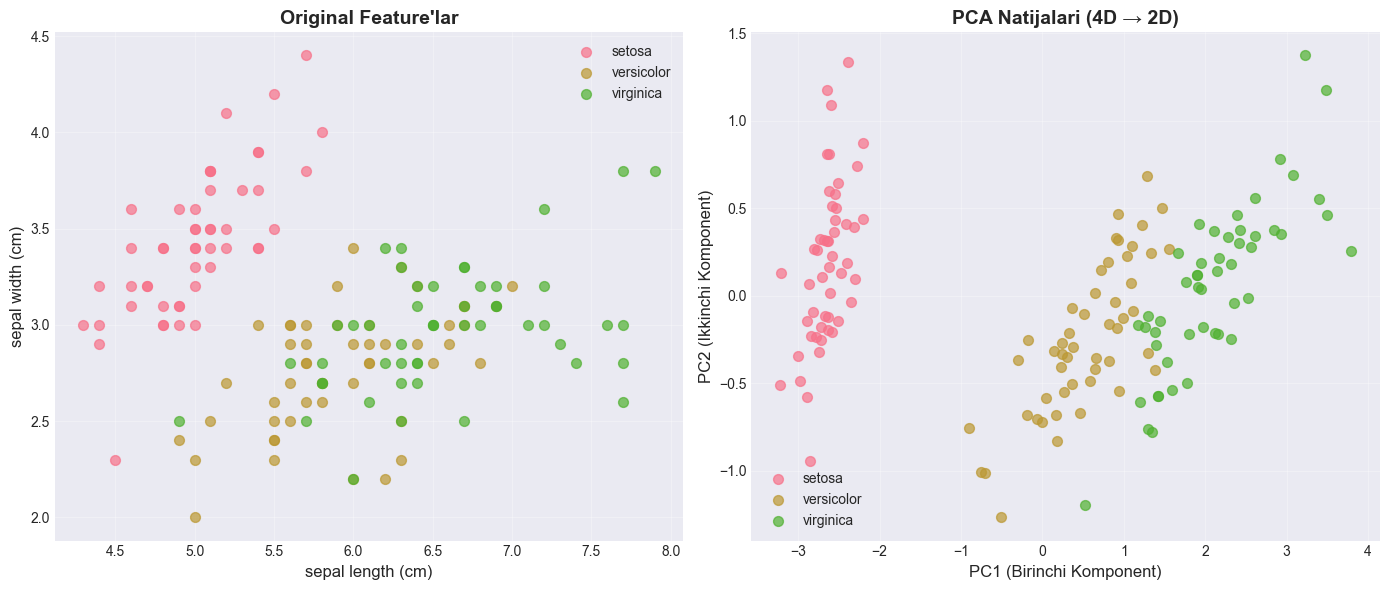

In [11]:
# Vizualizatsiya
plt.figure(figsize=(14, 6))

# Subplot 1: Original feature'lar (2 ta tanlangan)
plt.subplot(1, 2, 1)
for i, name in enumerate(target_names):
    plt.scatter(X[y==i, 0], X[y==i, 1], label=name, alpha=0.7, s=50)
plt.xlabel(feature_names[0], fontsize=12)
plt.ylabel(feature_names[1], fontsize=12)
plt.title('Original Feature\'lar', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: PCA komponentlari
plt.subplot(1, 2, 2)
for i, name in enumerate(target_names):
    plt.scatter(X_pca[y==i, 0], X_pca[y==i, 1], label=name, alpha=0.7, s=50)
plt.xlabel('PC1 (Birinchi Komponent)', fontsize=12)
plt.ylabel('PC2 (Ikkinchi Komponent)', fontsize=12)
plt.title('PCA Natijalari (4D → 2D)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3️⃣ Reinforcement Learning (Mustahkamlovchi o'qitish)

### Ta'rif
Reinforcement Learning - bu **agent** muhitda harakatlar qiladi va **mukofot** (reward) yoki **jazo** (penalty) orqali o'rganadi.

### Asosiy komponentlar:

1. **Agent:** O'rganuvchi va qaror qabul qiluvchi
2. **Environment (Muhit):** Agent ta'sir qiluvchi tizim
3. **State (Holat):** Muhitning hozirgi holati
4. **Action (Harakat):** Agent qilishi mumkin bo'lgan harakat
5. **Reward (Mukofot):** Harakatning natijasi

### Ishlash jarayoni:
```
1. Agent holatni kuzatadi
2. Harakat tanlaydi
3. Muhit yangi holatga o'tadi
4. Agent mukofot/jazo oladi
5. Agent strategiyasini yangilaydi
6. Takrorlash...
```

### Qo'llanilishi:
- 🎮 O'yinlar (AlphaGo, Dota 2)
- 🤖 Robotika
- 🚗 Avtonom transport
- 💰 Trading strategiyalari
- 🏭 Sanoat avtomatizatsiyasi
- 🌡️ Temperatura nazorati

### 🎮 Misol 5: Q-Learning - Grid World Game

In [12]:
# Oddiy grid world o'yini
# Agent maqsadga yetish uchun eng yaxshi yo'lni o'rganadi

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

class GridWorld:
    def __init__(self, size=5):
        self.size = size
        self.start = (0, 0)
        self.goal = (size-1, size-1)
        self.obstacles = [(1, 1), (2, 2), (3, 1)]
        self.reset()
    
    def reset(self):
        self.agent_pos = list(self.start)
        return tuple(self.agent_pos)
    
    def step(self, action):
        # Actions: 0=up, 1=right, 2=down, 3=left
        moves = [(-1, 0), (0, 1), (1, 0), (0, -1)]
        move = moves[action]
        
        new_pos = [self.agent_pos[0] + move[0], self.agent_pos[1] + move[1]]
        
        # Chegaralarni tekshirish
        if (0 <= new_pos[0] < self.size and 0 <= new_pos[1] < self.size and
            tuple(new_pos) not in self.obstacles):
            self.agent_pos = new_pos
        
        # Reward berish
        if tuple(self.agent_pos) == self.goal:
            return tuple(self.agent_pos), 100, True  # state, reward, done
        else:
            return tuple(self.agent_pos), -1, False

# Q-Learning algoritmi
class QLearningAgent:
    def __init__(self, states, actions, learning_rate=0.1, discount=0.95, epsilon=0.1):
        self.q_table = {}
        for state in states:
            self.q_table[state] = np.zeros(actions)
        self.lr = learning_rate
        self.gamma = discount
        self.epsilon = epsilon
        self.actions = actions
    
    def get_action(self, state):
        # Epsilon-greedy strategy
        if np.random.random() < self.epsilon:
            return np.random.randint(self.actions)
        else:
            return np.argmax(self.q_table[state])
    
    def update(self, state, action, reward, next_state):
        current_q = self.q_table[state][action]
        max_next_q = np.max(self.q_table[next_state])
        new_q = current_q + self.lr * (reward + self.gamma * max_next_q - current_q)
        self.q_table[state][action] = new_q

print("🎮 Grid World o'yini")
print("="*50)
print("Maqsad: Agent (🤖) maqsadga (🎯) yetishi kerak")
print("To'siqlar (⬛): ", end="")
env = GridWorld()
print(env.obstacles)

🎮 Grid World o'yini
Maqsad: Agent (🤖) maqsadga (🎯) yetishi kerak
To'siqlar (⬛): [(1, 1), (2, 2), (3, 1)]


In [13]:
# O'qitish jarayoni
env = GridWorld(size=5)
states = [(i, j) for i in range(5) for j in range(5)]
agent = QLearningAgent(states, 4, learning_rate=0.1, discount=0.95, epsilon=0.2)

episodes = 1000
rewards_history = []

print(f"\n🎓 O'qitish boshlandi...")
print(f"Episodlar soni: {episodes}")

for episode in range(episodes):
    state = env.reset()
    total_reward = 0
    steps = 0
    
    while steps < 100:  # Maksimal qadamlar
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)
        agent.update(state, action, reward, next_state)
        
        state = next_state
        total_reward += reward
        steps += 1
        
        if done:
            break
    
    rewards_history.append(total_reward)
    
    if (episode + 1) % 200 == 0:
        avg_reward = np.mean(rewards_history[-100:])
        print(f"  Episode {episode+1}: O'rtacha reward = {avg_reward:.2f}")

print(f"\n✅ O'qitish yakunlandi!")


🎓 O'qitish boshlandi...
Episodlar soni: 1000
  Episode 200: O'rtacha reward = 90.79
  Episode 400: O'rtacha reward = 91.18
  Episode 600: O'rtacha reward = 90.84
  Episode 800: O'rtacha reward = 91.44
  Episode 1000: O'rtacha reward = 91.19

✅ O'qitish yakunlandi!


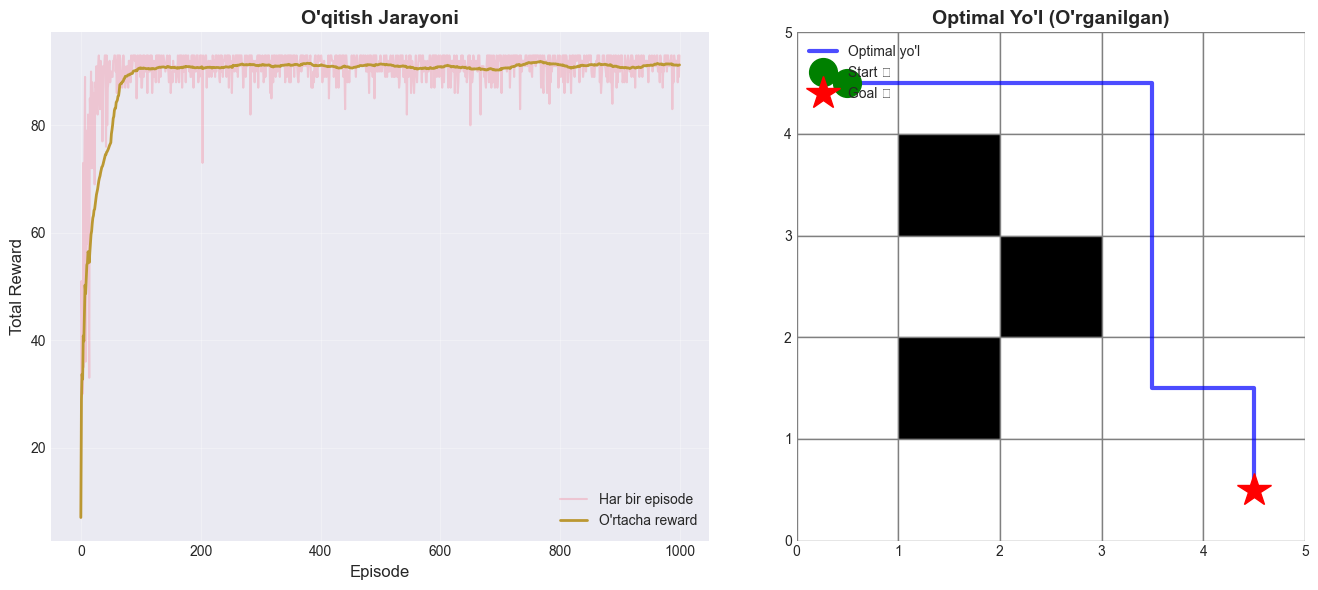


🎯 Natijalar:
Optimal yo'l uzunligi: 8 qadam
Yo'l: (0, 0) → (0, 1) → (0, 2) → (0, 3) → (1, 3) → (2, 3) → (3, 3) → (3, 4) → (4, 4)


In [14]:
# Vizualizatsiya
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: O'qitish jarayoni
ax1 = axes[0]
ax1.plot(rewards_history, alpha=0.3, label='Har bir episode')
# O'rtacha reward (100 episodlik oyna)
window = 50
avg_rewards = [np.mean(rewards_history[max(0, i-window):i+1]) 
               for i in range(len(rewards_history))]
ax1.plot(avg_rewards, linewidth=2, label='O\'rtacha reward')
ax1.set_xlabel('Episode', fontsize=12)
ax1.set_ylabel('Total Reward', fontsize=12)
ax1.set_title('O\'qitish Jarayoni', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2: Optimal yo'l
ax2 = axes[1]
# Grid chizish
for i in range(env.size):
    for j in range(env.size):
        if (i, j) in env.obstacles:
            ax2.add_patch(Rectangle((j, env.size-1-i), 1, 1, 
                                   facecolor='black', edgecolor='gray'))
        else:
            ax2.add_patch(Rectangle((j, env.size-1-i), 1, 1, 
                                   facecolor='white', edgecolor='gray'))

# Agent yo'lini ko'rsatish
state = env.reset()
path = [state]
for _ in range(20):
    action = np.argmax(agent.q_table[state])
    next_state, _, done = env.step(action)
    path.append(next_state)
    if done:
        break
    state = next_state

# Yo'lni chizish
path_x = [p[1] + 0.5 for p in path]
path_y = [env.size - 1 - p[0] + 0.5 for p in path]
ax2.plot(path_x, path_y, 'b-', linewidth=3, alpha=0.7, label='Optimal yo\'l')
ax2.plot(path_x[0], path_y[0], 'go', markersize=20, label='Start 🤖')
ax2.plot(path_x[-1], path_y[-1], 'r*', markersize=25, label='Goal 🎯')

ax2.set_xlim(0, env.size)
ax2.set_ylim(0, env.size)
ax2.set_aspect('equal')
ax2.set_title('Optimal Yo\'l (O\'rganilgan)', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left')
ax2.set_xticks(range(env.size+1))
ax2.set_yticks(range(env.size+1))
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"\n🎯 Natijalar:")
print(f"Optimal yo'l uzunligi: {len(path)-1} qadam")
print(f"Yo'l: {' → '.join([str(p) for p in path])}")

---
## 📊 ML Turlarini Taqqoslash

| Xususiyat | Supervised | Unsupervised | Reinforcement |
|-----------|-----------|-------------|---------------|
| **Ma'lumotlar** | Belgilangan | Belgisiz | Sequential |
| **Maqsad** | Bashorat qilish | Naqsh topish | Optimal strategiya |
| **Feedback** | To'g'ri javob | Yo'q | Mukofot/jazo |
| **Misollar** | Klassifikatsiya, Regressiya | Clustering, PCA | Robotika, O'yinlar |
| **Qiyinlik** | O'rtacha | O'rtacha | Yuqori |
| **Ma'lumotlar** | Ko'p kerak | Kam kerak | Juda ko'p kerak |

## 🔄 Machine Learning Workflow

### 1. Problem Aniqlash
- Nimani hal qilmoqchisiz?
- Qanday natija kutilmoqda?
- Bu qaysi ML turiga kiradi?

### 2. Ma'lumotlarni To'plash
- Ma'lumot manbalari
- Ma'lumot sifati
- Yetarli miqdorda ma'lumot

### 3. Ma'lumotlarni Tayyorlash
- Tozalash (cleaning)
- Transformatsiya
- Feature engineering

### 4. Model Tanlash
- Muammoga mos algoritm
- Oddiy modeldan boshlash
- Murakkab modellarga o'tish

### 5. Model O'qitish
- Train/test split
- Model fit qilish
- Hyperparameter tuning

### 6. Model Baholash
- Metrikalarga qarash
- Overfitting tekshirish
- Cross-validation

### 7. Deployment
- Modelni ishlatishga tayyorlash
- Monitoring
- Yangilab turish

In [15]:
# ML Workflow misoli - To'liq jarayon
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("🔬 To'liq ML Workflow Misoli")
print("="*60)

# 1. Ma'lumotlarni yuklash
print("\n1️⃣ Ma'lumotlarni yuklash...")
data = load_breast_cancer()
X, y = data.data, data.target
print(f"   Ma'lumotlar: {X.shape[0]} namuna, {X.shape[1]} feature")
print(f"   Target: {data.target_names}")

# 2. Ma'lumotlarni bo'lish
print("\n2️⃣ Train/Test split...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"   Train: {X_train.shape[0]} namuna")
print(f"   Test: {X_test.shape[0]} namuna")

# 3. Ma'lumotlarni masshtablash
print("\n3️⃣ Feature scaling...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("   ✅ Scaling yakunlandi")

# 4. Bir nechta model sinab ko'rish
print("\n4️⃣ Turli modellarni sinash...")
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=10000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

results = {}
for name, model in models.items():
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    
    # Train va test
    model.fit(X_train_scaled, y_train)
    train_score = model.score(X_train_scaled, y_train)
    test_score = model.score(X_test_scaled, y_test)
    
    results[name] = {
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'train': train_score,
        'test': test_score
    }
    
    print(f"\n   📊 {name}:")
    print(f"      CV Score: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
    print(f"      Train Score: {train_score:.4f}")
    print(f"      Test Score: {test_score:.4f}")

# 5. Eng yaxshi modelni tanlash
print("\n5️⃣ Eng yaxshi model:")
best_model_name = max(results.items(), key=lambda x: x[1]['test'])[0]
best_model = models[best_model_name]
print(f"   🏆 {best_model_name}")
print(f"   Test aniqlik: {results[best_model_name]['test']:.4f}")

🔬 To'liq ML Workflow Misoli

1️⃣ Ma'lumotlarni yuklash...
   Ma'lumotlar: 569 namuna, 30 feature
   Target: ['malignant' 'benign']

2️⃣ Train/Test split...
   Train: 455 namuna
   Test: 114 namuna

3️⃣ Feature scaling...
   ✅ Scaling yakunlandi

4️⃣ Turli modellarni sinash...

   📊 Logistic Regression:
      CV Score: 0.9736 (±0.0179)
      Train Score: 0.9868
      Test Score: 0.9737

   📊 Decision Tree:
      CV Score: 0.9165 (±0.0179)
      Train Score: 1.0000
      Test Score: 0.9474

   📊 Random Forest:
      CV Score: 0.9582 (±0.0176)
      Train Score: 1.0000
      Test Score: 0.9649

5️⃣ Eng yaxshi model:
   🏆 Logistic Regression
   Test aniqlik: 0.9737


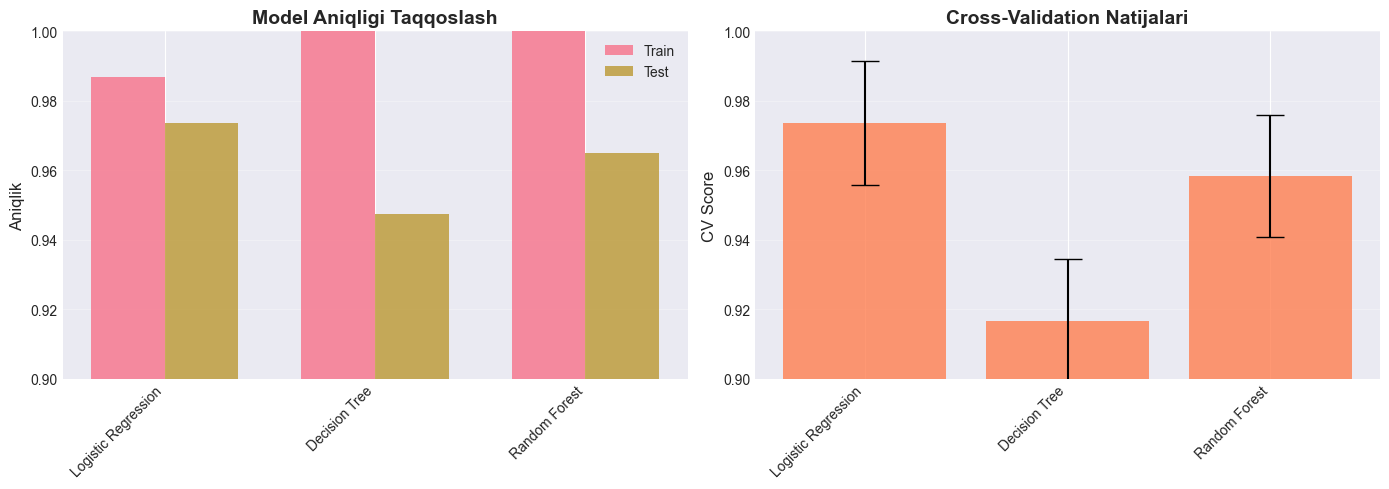

In [16]:
# Modellarni taqqoslash vizualizatsiyasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Model aniqlik taqqoslash
ax1 = axes[0]
model_names = list(results.keys())
train_scores = [results[m]['train'] for m in model_names]
test_scores = [results[m]['test'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

ax1.bar(x - width/2, train_scores, width, label='Train', alpha=0.8)
ax1.bar(x + width/2, test_scores, width, label='Test', alpha=0.8)
ax1.set_ylabel('Aniqlik', fontsize=12)
ax1.set_title('Model Aniqligi Taqqoslash', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim([0.9, 1.0])

# Subplot 2: CV Score taqqoslash
ax2 = axes[1]
cv_means = [results[m]['cv_mean'] for m in model_names]
cv_stds = [results[m]['cv_std'] for m in model_names]

ax2.bar(model_names, cv_means, yerr=cv_stds, capsize=10, alpha=0.8, color='coral')
ax2.set_ylabel('CV Score', fontsize=12)
ax2.set_title('Cross-Validation Natijalari', fontsize=14, fontweight='bold')
ax2.set_xticklabels(model_names, rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim([0.9, 1.0])

plt.tight_layout()
plt.show()

## 💡 Xulosa

### Bu darsda o'rgandik:

1. **Machine Learning nima va nima uchun muhim**
   - An'anaviy dasturlashdan farqi
   - Real hayotdagi qo'llanilishi

2. **Supervised Learning**
   - Classification: Ma'lumotlarni toifalarga ajratish
   - Regression: Raqamli qiymatlarni bashorat qilish
   - Misollar: Email spam, uy narxi

3. **Unsupervised Learning**
   - Clustering: O'xshash ma'lumotlarni guruhlash
   - Dimensionality Reduction: Ma'lumot o'lchamini kamaytirish
   - Misollar: Mijozlar segmentatsiyasi, PCA

4. **Reinforcement Learning**
   - Agent muhitda harakatlar qiladi
   - Mukofot/jazo orqali o'rganadi
   - Misollar: O'yinlar, robotika

5. **ML Workflow**
   - Problem → Ma'lumotlar → Tayyorlash → Model → O'qitish → Baholash → Deployment

### Keyingi darsda:
- Supervised Learning: Classification algoritmlari batafsil
- Model baholash metrikalari
- Overfitting va Underfitting

## 📚 Qo'shimcha Mashqlar

1. **Supervised Learning**: O'zingizning klassifikatsiya modelingizni yarating
2. **Unsupervised Learning**: Boshqa datasetda clustering qo'llang
3. **Reinforcement Learning**: Grid size'ni o'zgartirib, modelni qayta o'rgating
4. **Comparison**: Uch turni real hayot misollarida taqqoslang

---

### 🎓 Savol va Topshiriqlar

1. Machine Learning qanday vaziyatlarda an'anaviy dasturlashdan yaxshiroq?
2. Supervised va Unsupervised Learning orasidagi asosiy farq nima?
3. Qaysi holatda Reinforcement Learning ishlatish kerak?
4. Overfitting nima va uni qanday oldini olish mumkin?
5. Cross-validation nima uchun muhim?

**Uy vazifasi:** `homework.md` faylini tekshiring!